In [3]:
import sys
import os

# Add parent directory of the notebook to sys.path
sys.path.append(os.path.abspath(".."))

In [4]:
import numpy as np
import pickle as pkl
from utils import *
from utils_plot import *
from tqdm import tqdm
import os
from utils_simple_access import *
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec


# Run scan_L_A.py to generate the results for Fig2.ipynb


In [9]:
# Run scan_L_A.py to generate the results for Fig2.ipynb

# Create an empty DataFrame with the specified headers
df = pd.DataFrame(columns=['L', 'A', 'NC1', 'PR', 'order'])

if os.path.exists('sweep_S_A_seed_circular_df.csv'):
    os.remove('sweep_S_A_seed_circular_df.csv')

result_files = glob.glob('../results/sweep_S_A_seed_circular/*')

for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    S = data_dict['C'].length_corridors[0]
    if L ==0:
        continue
    A = data_dict['C'].max_move
    if data_dict['accuracy_l'][-1] < 0.99:
        print(f"A={A}, L={L}, accuracy={data_dict['accuracy_l'][-1]}")
        plt.plot(data_dict['accuracy_l'])
        plt.show()
    action_taken = data_dict['action_taken']
    data_dict['X'] = data_dict['X'][abs(action_taken) <= 1]
    data_dict['y'] = data_dict['y'][abs(action_taken) <= 1]
    data_dict['hidden_states'][-1] = data_dict['hidden_states'][-1][abs(action_taken) <= 1]
    data_dict['loc_y'] = data_dict['loc_y'][abs(action_taken) <= 1]
    NC1 = calc_NC1_from_data_dict(data_dict)
    PR = calc_PR(data_dict['hidden_states'][-1].cpu().numpy())
    order = get_order(data_dict)

    df = pd.concat([df, pd.DataFrame([{
        'S': S,
        'A': A,
        'NC1': np.log10(NC1),
        'PR': abs(PR),
        'order': order
    }])], ignore_index=True)


df.to_csv('sweep_S_A_seed_circular_df.csv', index=False)


  0%|          | 0/627 [00:00<?, ?it/s]/tmp/ipykernel_1997999/1432892904.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([{
100%|██████████| 627/627 [04:29<00:00,  2.33it/s]


In [7]:


df.to_csv('sweep_S_A_seed_circular_df.csv', index=False)

In [4]:
# Set global matplotlib formatting for ICLR paper compatibility
# Set global font to Times New Roman

mpl.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 22,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'lines.markersize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'figure.figsize': (6, 4),
    'pdf.fonttype': 42,  # TrueType fonts for compatibility
    'ps.fonttype': 42,
    'text.usetex': False,  # Set to True if you want LaTeX rendering and have it installed
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'serif'],
})

import seaborn as sns
sns.set_context("paper")
sns.set_style("whitegrid")


In [5]:
df

,L,A,NC1,PR,order,S
0,NaN,18,-3.866108,1.704473,0.981702,36.0
1,NaN,23,-4.040871,2.686454,0.874976,46.0
2,NaN,8,-4.500028,1.615925,0.972520,19.0
3,NaN,26,-3.466742,1.578060,0.949290,47.0
4,NaN,7,-4.280675,1.421936,0.972463,17.0
...,...,...,...,...,...,...
11395,NaN,18,-3.596475,1.810425,0.989093,44.0
11396,NaN,23,-3.600602,1.676416,0.912781,28.0
11397,NaN,36,-3.409407,1.927219,0.980740,46.0
11398,NaN,18,-3.983863,1.689344,0.965220,26.0


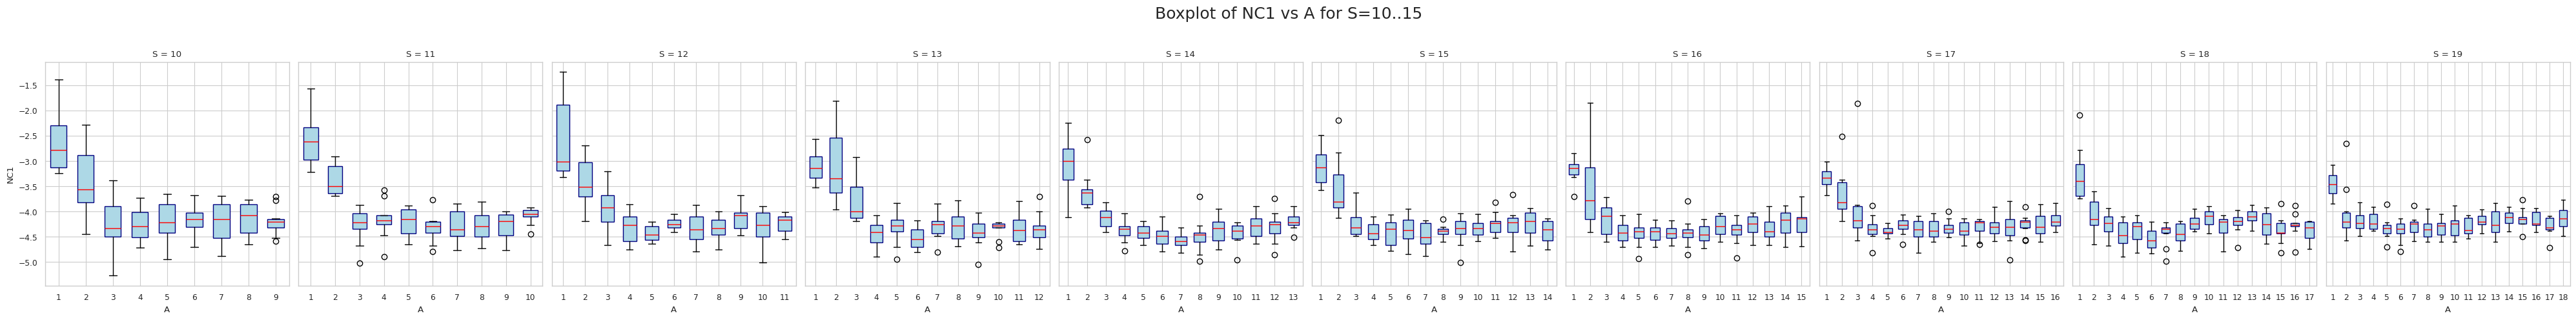

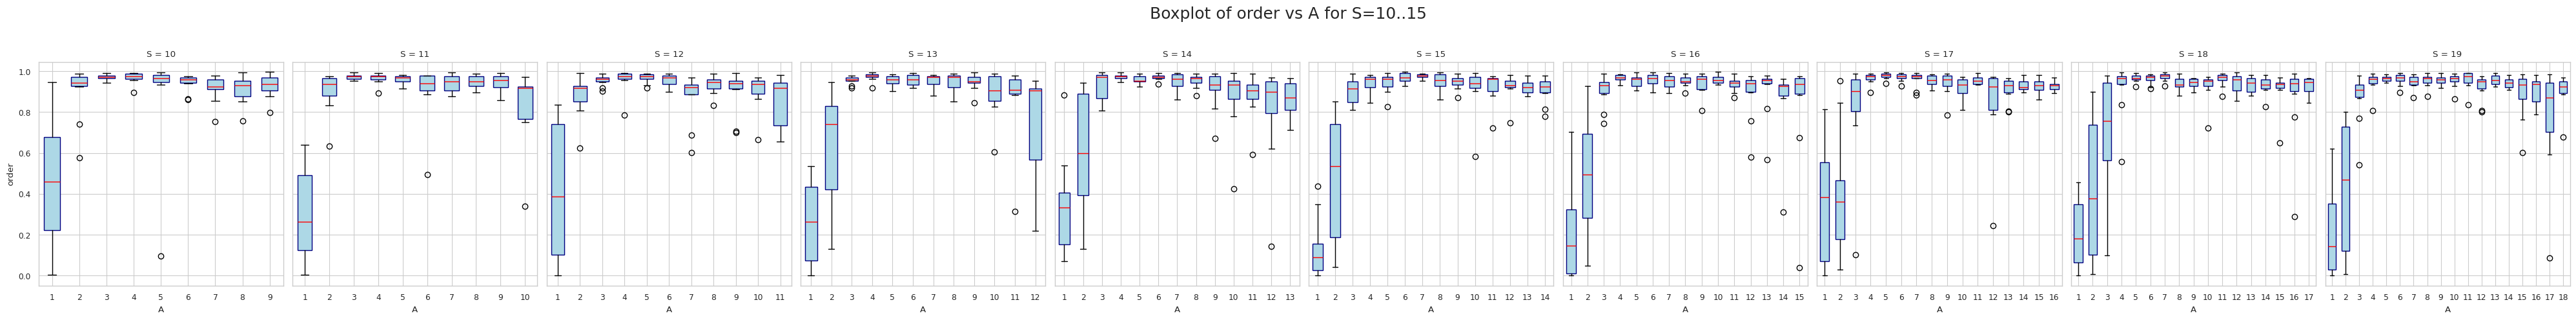

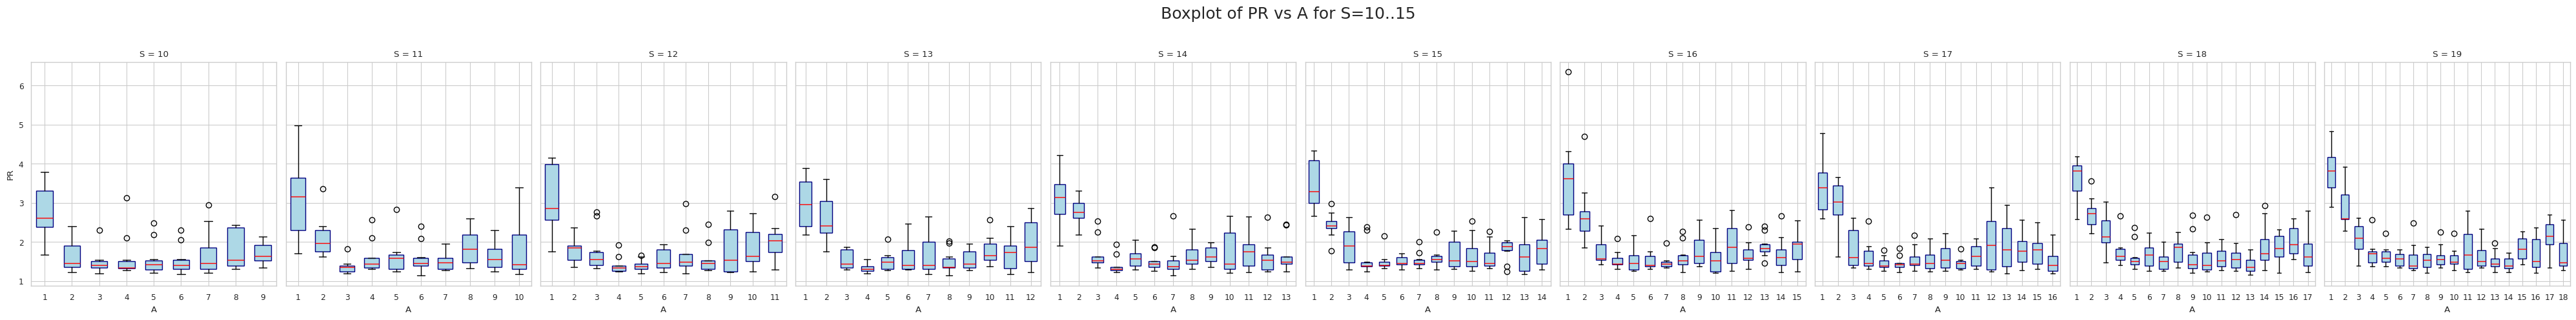

In [6]:
import matplotlib.pyplot as plt

# We'll use the DataFrame `df` from cell 5, which should have columns:
# 'A', 'S', 'NC1', 'margins', 'order', 'PR', etc.
# We'll plot for S in 10..15 (inclusive), for each metric.

metrics = ['NC1', 'order', 'PR']
S_values = list(range(10, 20))
A_col = 'A'
S_col = 'S'

for metric in metrics:
    fig, axes = plt.subplots(1, len(S_values), figsize=(4*len(S_values), 5), sharey=True)
    for i, S_val in enumerate(S_values):
        ax = axes[i] if len(S_values) > 1 else axes
        # Select rows with S == S_val
        df_S = df[df[S_col] == S_val]
        # Drop NaN in A or metric
        df_S = df_S[[A_col, metric]].dropna()
        # Sort A for consistent x-axis
        A_sorted = sorted(df_S[A_col].unique())
        # Prepare data for boxplot: list of arrays, one per A
        data = [df_S[df_S[A_col] == a][metric].values for a in A_sorted]
        ax.boxplot(data, positions=A_sorted, widths=0.6, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red'))
        ax.set_title(f"S = {S_val}")
        ax.set_xlabel("A")
        if i == 0:
            ax.set_ylabel(metric)
        ax.set_xticks(A_sorted)
    fig.suptitle(f"Boxplot of {metric} vs A for S=10..15", fontsize=18)
    fig.savefig(f"./final_results/figures/boxplot_{metric}.png", dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


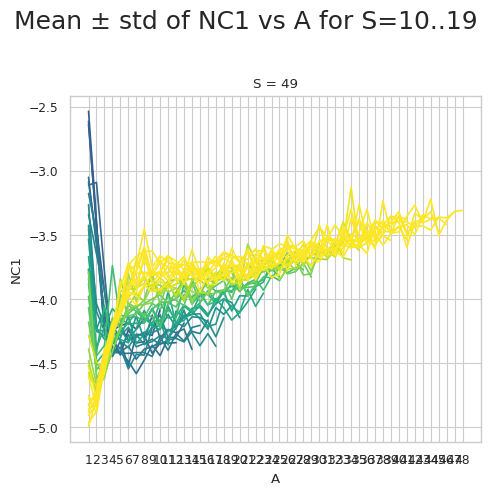

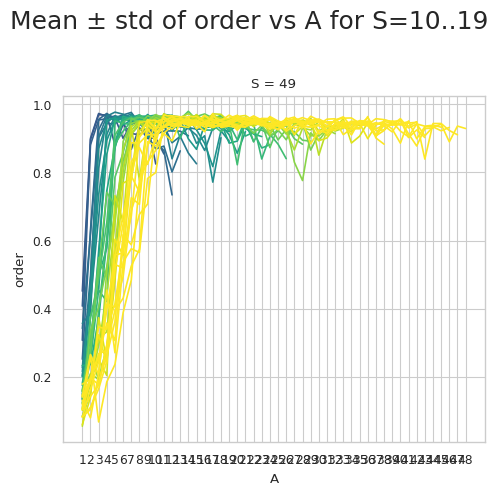

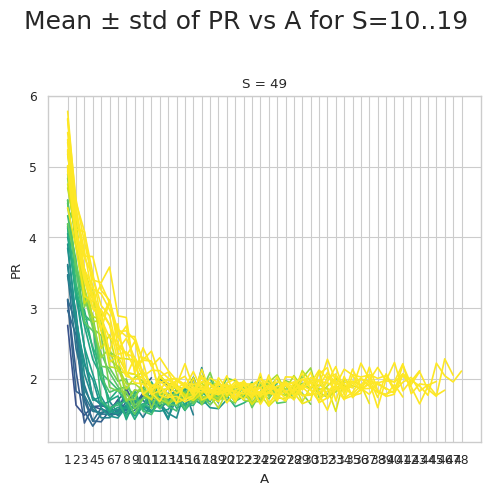

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# We'll use the DataFrame `df` from cell 5, which should have columns:
# 'A', 'S', 'NC1', 'margins', 'order', 'PR', etc.
# We'll plot for S in 10..19 (inclusive), for each metric.

metrics = ['NC1', 'order', 'PR']
S_values = list(range(10, 50))
A_col = 'A'
S_col = 'S'

for metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharey=True)
    for i, S_val in enumerate(S_values):
        # Select rows with S == S_val
        df_S = df[df[S_col] == S_val]
        # Drop NaN in A or metric
        df_S = df_S[[A_col, metric]].dropna()
        # Sort A for consistent x-axis
        A_sorted = sorted(df_S[A_col].unique())
        means = []
        stds = []
        for a in A_sorted:
            vals = df_S[df_S[A_col] == a][metric].values
            means.append(np.mean(vals) if len(vals) > 0 else np.nan)
            stds.append(np.std(vals) if len(vals) > 0 else np.nan)
        means = np.array(means)
        stds = np.array(stds)
        # Use a viridis colormap and progress color with i
        import matplotlib.cm as cm
        import matplotlib.colors as mcolors
        cmap = plt.get_cmap('viridis')
        norm = mcolors.Normalize(vmin=0, vmax=len(S_values)-1)
        color = cmap(norm(S_val))
        ax.plot(A_sorted, means, color=color)
        ax.set_title(f"S = {S_val}")
        ax.set_xlabel("A")
        if i == 0:
            ax.set_ylabel(metric)
        ax.set_xticks(A_sorted)
    fig.suptitle(f"Mean ± std of {metric} vs A for S=10..19", fontsize=18)
    fig.savefig(f"./final_results/figures/meanstd_{metric}.png", dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# We'll use the DataFrame `df` from cell 5, which should have columns:
# 'A', 'S', 'NC1', 'margins', 'order', 'PR', etc.
# We'll plot for S in 10..19 (inclusive), for each metric.

metrics = ['NC1', 'order', 'PR']
S_values = list(range(10, 50))
A_col = 'A'
S_col = 'S'

for metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(5, 5), sharey=True)
    for i, S_val in enumerate(S_values):
        # Select rows with S == S_val
        df_S = df[df[S_col] == S_val]
        # Drop NaN in A or metric
        df_S = df_S[[A_col, metric]].dropna()
        # Sort A for consistent x-axis
        A_sorted = sorted(df_S[A_col].unique())
        means = []
        stds = []
        for a in A_sorted:
            vals = df_S[df_S[A_col] == a][metric].values
            means.append(np.mean(vals) if len(vals) > 0 else np.nan)
            stds.append(np.std(vals) if len(vals) > 0 else np.nan)
        means = np.array(means)
        stds = np.array(stds)
        # Use a viridis colormap and progress color with i
        import matplotlib.cm as cm
        import matplotlib.colors as mcolors
        cmap = plt.get_cmap('viridis')
        norm = mcolors.Normalize(vmin=0, vmax=len(S_values)-1)
        color = cmap(norm(S_val))
        ax.plot(A_sorted, means, color=color)
        ax.set_title(f"S = {S_val}")
        ax.set_xlabel("A")
        if i == 0:
            ax.set_ylabel(metric)
        ax.set_xticks(A_sorted)
    fig.suptitle(f"Mean ± std of {metric} vs A for S=10..19", fontsize=18)
    fig.savefig(f"./final_results/figures/meanstd_{metric}.png", dpi=300)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


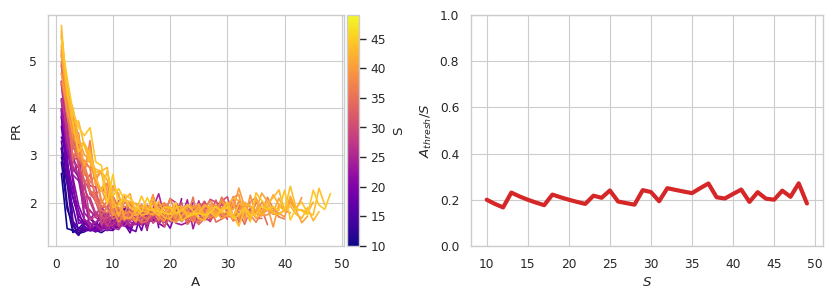

In [86]:

metrics = ['order', 'PR']
S_values = np.arange(10, 50)
A_col = 'A'
S_col = 'S'
metric = 'PR'
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
line = []
for i, S_val in enumerate(S_values):
    # Select rows with S == S_val
    df_S = df[df[S_col] == S_val]
    # Drop NaN in A or metric
    df_S = df_S[[A_col, metric]].dropna()
    # Sort A for consistent x-axis
    A_sorted = sorted(df_S[A_col].unique())
    means = []
    stds = []
    for a in A_sorted:
        vals = df_S[df_S[A_col] == a][metric].values
        means.append(np.median(vals) if len(vals) > 0 else np.nan)
        stds.append(np.std(vals) if len(vals) > 0 else np.nan)
    # Smooth the means using a simple moving average with window size 3
    import numpy as np
    def smooth(x, window=3):
        if len(x) < window:
            return x
        return np.convolve(x, np.ones(window)/window, mode='same')
    means = np.array(means)
    # means = smooth(means, window=3)
    if metric == 'PR':
        line.append((np.where(means<2)[0][0]+1)/S_val)
    elif metric == 'order':
        line.append((np.where(means>0.95)[0][0]+1)/S_val)
    # line.append(means)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    cmap = plt.get_cmap('plasma')
    norm = mcolors.Normalize(vmin=S_values.min(), vmax=S_values.max()+5)
    color = cmap(norm(S_val))
    axs[0].plot(A_sorted, means, color=color, label=f"S={S_val}")
    axs[0].set_xlabel("A")
    axs[0].set_ylabel(metric)
    # axs[0].set_ylim(min=1)
# axs[0].set_xticks(A_sorted[np.linspace(0, len(A_sorted)-1, 5).astype(int)])

# Add colorbar after the loop
import matplotlib.cm as cm
import matplotlib.colors as mcolors
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=min(S_values), vmax=max(S_values))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs[0], pad=0.01)
cbar.set_label('S')
axs[1].plot(S_values, line, lw=3, c='tab:red')
axs[1].set_xlabel(r'$S$')
axs[1].set_ylabel(r'$A_{thresh}/S$')
plt.ylim(0, 1)
fig.savefig(f"./final_results/figures/fig_S_scaling.png", dpi=300, bbox_inches='tight')
plt.show()


0it [00:00, ?it/s]

40it [00:26,  1.52it/s]


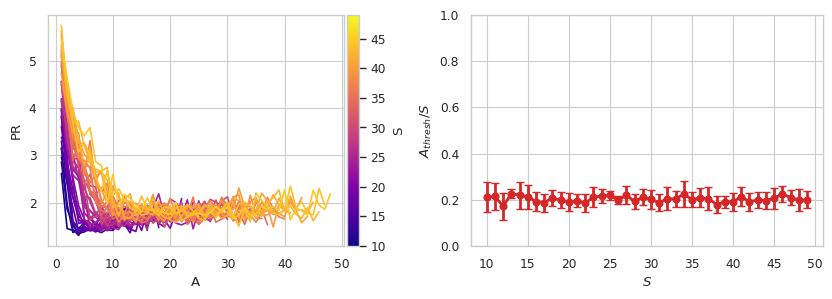

In [106]:

metrics = ['order', 'PR']
S_values = np.arange(10, 50)
A_col = 'A'
S_col = 'S'
metric = 'PR'
fig, axs = plt.subplots(1, 2, figsize=(10, 3))
thresh_arr = np.zeros((len(S_values), 100))
for i, S_val in tqdm(enumerate(S_values)):
    # Select rows with S == S_val
    df_S = df[df[S_col] == S_val]
    # Drop NaN in A or metric
    df_S = df_S[[A_col, metric]].dropna()
    # Sort A for consistent x-axis
    A_sorted = sorted(df_S[A_col].unique())
    for j in range(100):
        vals = []
        for a in A_sorted:
            val = np.random.choice(df_S[df_S[A_col] == a][metric].values)
            vals.append(val)
        vals = np.array(vals)
        if metric == 'PR':
            thresh_arr[i, j] = (np.where(vals<2)[0][0]+1)/S_val
        elif metric == 'order':
            thresh_arr[i, j] = (np.where(vals>0.95)[0][0]+1)/S_val
    means = []
    stds = []
    for a in A_sorted:
        vals = df_S[df_S[A_col] == a][metric].values
        means.append(np.median(vals) if len(vals) > 0 else np.nan)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors
    cmap = plt.get_cmap('plasma')
    norm = mcolors.Normalize(vmin=S_values.min(), vmax=S_values.max()+5)
    color = cmap(norm(S_val))
    axs[0].plot(A_sorted, means, color=color, label=f"S={S_val}")
    axs[0].set_xlabel("A")
    axs[0].set_ylabel(metric)

# Add colorbar after the loop
import matplotlib.cm as cm
import matplotlib.colors as mcolors
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=min(S_values), vmax=max(S_values))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs[0], pad=0.01)
cbar.set_label('S')
import scipy.stats as stats
# Convert thresh_l_l to array for easier manipulation
means = np.mean(thresh_arr, axis=1)
sems = np.std(thresh_arr, axis=1)
axs[1].errorbar(S_values, means, yerr=sems, lw=2, c='tab:red', fmt='-o', capsize=3)
axs[1].set_xlabel(r'$S$')
axs[1].set_ylabel(r'$A_{thresh}/S$')
plt.ylim(0, 1)
fig.savefig(f"./final_results/figures/fig_S_scaling.png", dpi=300, bbox_inches='tight')
plt.show()


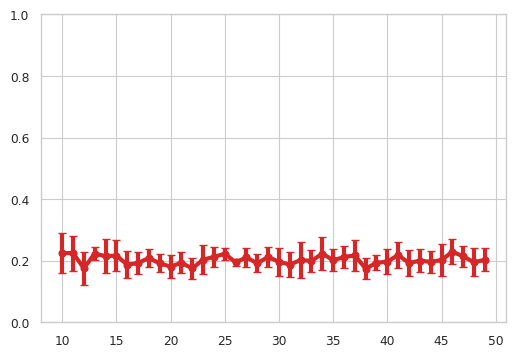

In [102]:

means = np.mean(thresh_arr, axis=1)
sems = np.std(thresh_arr, axis=1)
plt.errorbar(S_values, means, yerr=sems, lw=3, c='tab:red', fmt='-o', capsize=3)
plt.ylim(0, 1)
fig.savefig(f"./final_results/figures/fig_S_scaling.png", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:

# Create an empty DataFrame with the specified headers

result_files = glob.glob('../results/sweep_L_A/*')

A_l = []
Coverage_l = []
NC1_l = []
for file in tqdm(result_files):
    with open(file, 'rb') as f:
        data_dict = pkl.load(f)
    L = data_dict['C'].L
    if L != 5:
        continue
    A = data_dict['C'].max_move
    S = data_dict['C'].length_corridors[0]
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    coverage = (X.T@y)[:S,:S].mean()
    NC1 = calc_NC1_from_data_dict(data_dict)
    A_l.append(A)
    Coverage_l.append(coverage)
    NC1_l.append(NC1)
plt.scatter(Coverage_l, NC1_l, c=A_l, cmap='viridis')
plt.yscale('log')
plt.show()

In [ ]:

plt.scatter(A_l, Coverage_l, c=A_l, cmap='viridis')
# plt.yscale('log')
plt.show()